In [1]:
from masa.common.utils import make_env
import sys
sys.path.append('/vol/bitbucket/ma5923/_projects/provably-safe-policy-updates/rl_project')
from utils.shield_utils import synthesise_shield
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

%load_ext autoreload
%autoreload 2

In [2]:
from masa.envs.tabular import colour_grid_world as cgw
from masa.envs.tabular import colour_bomb_grid_world as cbgw
from masa.envs.tabular import colour_bomb_grid_world_v2 as cbgw2
from masa.envs.tabular import colour_bomb_grid_world_v3 as cbgw3

## COLOUR GRID WORLD

In [10]:
env = cgw.ColourGridWorld(render_mode='rgb_array', slip_prob=0.01)

output = synthesise_shield(
    env=env, 
    transition_matrix_fn=cgw.get_transition_matrix, 
    label_fn=cgw.label_fn, 
    cost_fn=cgw.cost_fn
)

Calculating the maximum number of successor states ...
Calculated maximum number of successor states [5] ...
Building successor state matrix and probabilities ...
Computing almost sure safe set ...


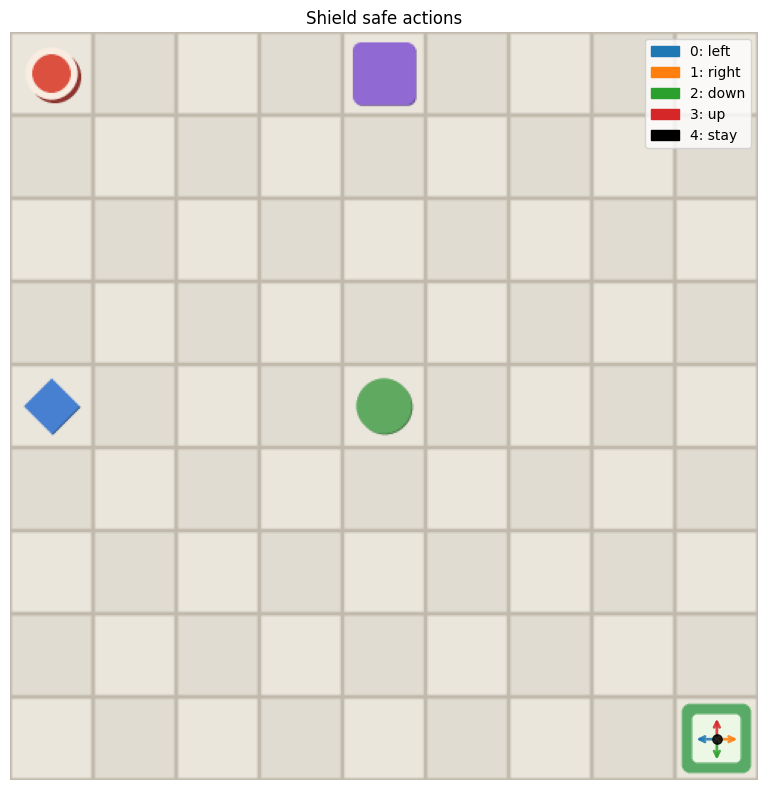

In [11]:
# output shape: (n_states, n_actions), 1 means action is safe
safe_actions_by_state = np.asarray(output)

ACTION_VECTORS = {
    0: (-1, 0),  # left
    1: (1, 0),   # right
    2: (0, 1),   # down
    3: (0, -1),  # up
    4: (0, 0),   # stay
}

ACTION_COLORS = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green",
    3: "tab:red",
    4: "black",
}

ACTION_LABELS = {
    0: "left",
    1: "right",
    2: "down",
    3: "up",
    4: "stay",
}


def plot_colour_bomb_safe_actions(env, safe_actions_by_state, *, title="Shield safe actions"):
    env.reset(seed=0)
    frame = env.render()

    grid_size = env.unwrapped._grid_size
    nrow = env.unwrapped._nrow
    ncol = env.unwrapped._ncol

    img_h, img_w = frame.shape[:2]
    cell_w = img_w / ncol
    cell_h = img_h / nrow

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(frame)
    ax.axis("off")
    ax.set_title(title)

    for state in range(safe_actions_by_state.shape[0]):
        row = state // grid_size
        col = state % grid_size

        cx = (col + 0.5) * cell_w
        cy = (row + 0.5) * cell_h

        safe_actions = np.flatnonzero(safe_actions_by_state[state] > 0)

        for action in safe_actions:
            dx_unit, dy_unit = ACTION_VECTORS[int(action)]
            color = ACTION_COLORS[int(action)]

            if action == 4:
                # Stay action: draw a small filled circle.
                ax.scatter(cx, cy, s=45, color=color, alpha=0.85, zorder=5)
                continue

            dx = dx_unit * cell_w * 0.28
            dy = dy_unit * cell_h * 0.28

            ax.annotate(
                "",
                xy=(cx + dx, cy + dy),
                xytext=(cx, cy),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=2.0,
                    alpha=0.85,
                ),
                zorder=5,
            )

    legend_handles = [
        mpatches.Patch(color=ACTION_COLORS[a], label=f"{a}: {ACTION_LABELS[a]}")
        for a in ACTION_VECTORS
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=True)

    plt.tight_layout()
    return fig, ax


fig, ax = plot_colour_bomb_safe_actions(env, output)
plt.show()

## Colour Bomb Grid World

In [5]:
env = cbgw.ColourBombGridWorld(render_mode='rgb_array', slip_prob=0.0)

output = synthesise_shield(env=env, transition_matrix_fn=cbgw.get_transition_matrix, label_fn=cbgw.label_fn, cost_fn=cbgw.cost_fn)

Calculating the maximum number of successor states ...
Calculated maximum number of successor states [5] ...
Building successor state matrix and probabilities ...
Computing almost sure safe set ...


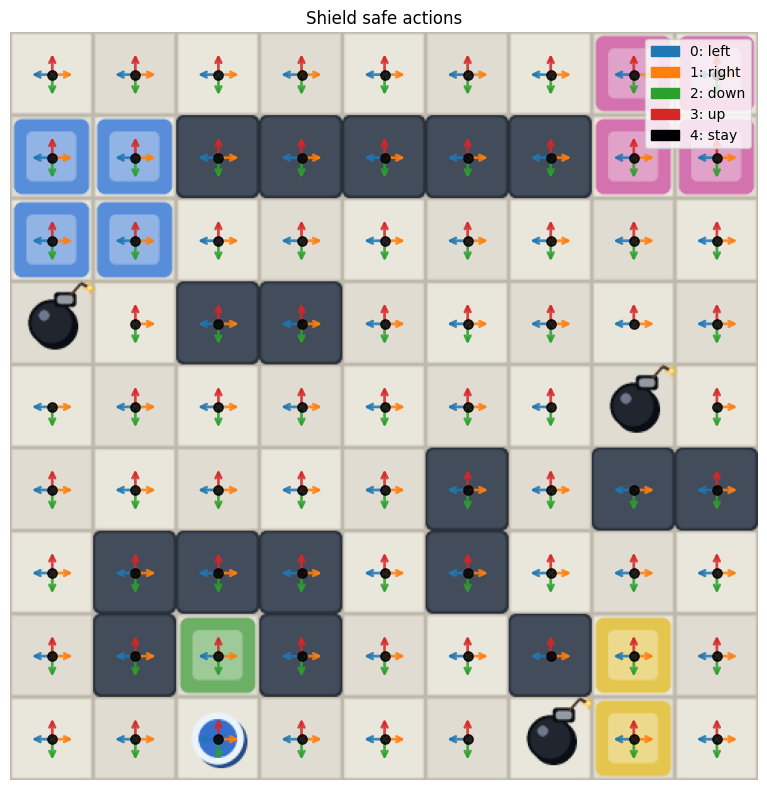

In [6]:
# output shape: (n_states, n_actions), 1 means action is safe
safe_actions_by_state = np.asarray(output)

ACTION_VECTORS = {
    0: (-1, 0),  # left
    1: (1, 0),   # right
    2: (0, 1),   # down
    3: (0, -1),  # up
    4: (0, 0),   # stay
}

ACTION_COLORS = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green",
    3: "tab:red",
    4: "black",
}

ACTION_LABELS = {
    0: "left",
    1: "right",
    2: "down",
    3: "up",
    4: "stay",
}


def plot_colour_bomb_safe_actions(env, safe_actions_by_state, *, title="Shield safe actions"):
    env.reset(seed=0)
    frame = env.render()

    grid_size = env.unwrapped._grid_size
    nrow = env.unwrapped._nrow
    ncol = env.unwrapped._ncol

    img_h, img_w = frame.shape[:2]
    cell_w = img_w / ncol
    cell_h = img_h / nrow

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(frame)
    ax.axis("off")
    ax.set_title(title)

    for state in range(safe_actions_by_state.shape[0]):
        row = state // grid_size
        col = state % grid_size

        cx = (col + 0.5) * cell_w
        cy = (row + 0.5) * cell_h

        safe_actions = np.flatnonzero(safe_actions_by_state[state] > 0)

        for action in safe_actions:
            dx_unit, dy_unit = ACTION_VECTORS[int(action)]
            color = ACTION_COLORS[int(action)]

            if action == 4:
                # Stay action: draw a small filled circle.
                ax.scatter(cx, cy, s=45, color=color, alpha=0.85, zorder=5)
                continue

            dx = dx_unit * cell_w * 0.28
            dy = dy_unit * cell_h * 0.28

            ax.annotate(
                "",
                xy=(cx + dx, cy + dy),
                xytext=(cx, cy),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=2.0,
                    alpha=0.85,
                ),
                zorder=5,
            )

    legend_handles = [
        mpatches.Patch(color=ACTION_COLORS[a], label=f"{a}: {ACTION_LABELS[a]}")
        for a in ACTION_VECTORS
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=True)

    plt.tight_layout()
    return fig, ax


fig, ax = plot_colour_bomb_safe_actions(env, output)
plt.show()

## ColourBombGridWorldV2

In [8]:
env = cbgw2.ColourBombGridWorldV2(render_mode='rgb_array', slip_prob=0.0)

output = synthesise_shield(env=env, transition_matrix_fn=cbgw.get_transition_matrix, label_fn=cbgw.label_fn, cost_fn=cbgw.cost_fn)

Calculating the maximum number of successor states ...
Calculated maximum number of successor states [5] ...
Building successor state matrix and probabilities ...
Computing almost sure safe set ...


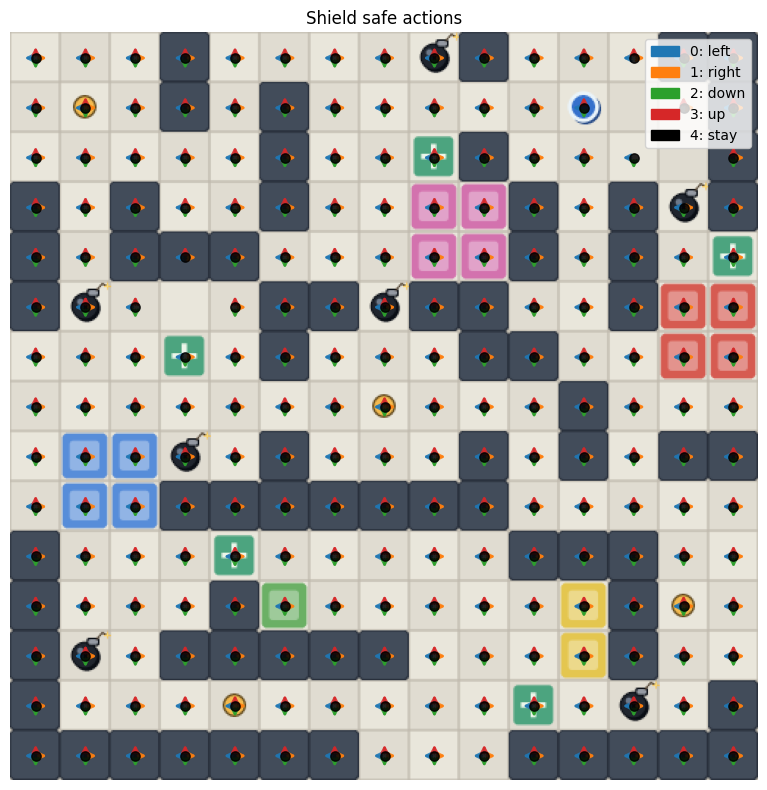

In [9]:
# output shape: (n_states, n_actions), 1 means action is safe
safe_actions_by_state = np.asarray(output)

ACTION_VECTORS = {
    0: (-1, 0),  # left
    1: (1, 0),   # right
    2: (0, 1),   # down
    3: (0, -1),  # up
    4: (0, 0),   # stay
}

ACTION_COLORS = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green",
    3: "tab:red",
    4: "black",
}

ACTION_LABELS = {
    0: "left",
    1: "right",
    2: "down",
    3: "up",
    4: "stay",
}


def plot_colour_bomb_safe_actions(env, safe_actions_by_state, *, title="Shield safe actions"):
    env.reset(seed=0)
    frame = env.render()

    grid_size = env.unwrapped._grid_size
    nrow = env.unwrapped._nrow
    ncol = env.unwrapped._ncol

    img_h, img_w = frame.shape[:2]
    cell_w = img_w / ncol
    cell_h = img_h / nrow

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(frame)
    ax.axis("off")
    ax.set_title(title)

    for state in range(safe_actions_by_state.shape[0]):
        row = state // grid_size
        col = state % grid_size

        cx = (col + 0.5) * cell_w
        cy = (row + 0.5) * cell_h

        safe_actions = np.flatnonzero(safe_actions_by_state[state] > 0)

        for action in safe_actions:
            dx_unit, dy_unit = ACTION_VECTORS[int(action)]
            color = ACTION_COLORS[int(action)]

            if action == 4:
                # Stay action: draw a small filled circle.
                ax.scatter(cx, cy, s=45, color=color, alpha=0.85, zorder=5)
                continue

            dx = dx_unit * cell_w * 0.28
            dy = dy_unit * cell_h * 0.28

            ax.annotate(
                "",
                xy=(cx + dx, cy + dy),
                xytext=(cx, cy),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=2.0,
                    alpha=0.85,
                ),
                zorder=5,
            )

    legend_handles = [
        mpatches.Patch(color=ACTION_COLORS[a], label=f"{a}: {ACTION_LABELS[a]}")
        for a in ACTION_VECTORS
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=True)

    plt.tight_layout()
    return fig, ax


fig, ax = plot_colour_bomb_safe_actions(env, output)
plt.show()

## ColourBombGridWorldV3

# BridgeCrossing

## BridgeCrossingV2